# Worksheet 5 — Final Google Colab Notebook  


 Mount Google Drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
import os

zip_file_path = '/content/drive/MyDrive/AI ML/collab/week5/Copy of FruitinAmazon.zip'
extraction_path = '/content/drive/MyDrive/AI ML/collab/week5/extracted_Fruit'

# Create the directory if it doesn't exist
os.makedirs(extraction_path, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f"'{zip_file_path}' extracted to '{extraction_path}' successfully.")

# List contents of the extracted directory to verify
print(f"Contents of '{extraction_path}':")
for root, dirs, files in os.walk(extraction_path):
    level = root.replace(extraction_path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f"{indent}{os.path.basename(root)}/")
    subindent = ' ' * 4 * (level + 1)
    for f in files:
        print(f"{subindent}{f}")


'/content/drive/MyDrive/AI ML/collab/week5/Copy of FruitinAmazon.zip' extracted to '/content/drive/MyDrive/AI ML/collab/week5/extracted_Fruit' successfully.
Contents of '/content/drive/MyDrive/AI ML/collab/week5/extracted_Fruit':
extracted_Fruit/
    FruitinAmazon/
        test/
            cupuacu/
                download (5).jpeg
                download (3).jpeg
                download (2).jpeg
                images (3).jpeg
                download (4).jpeg
            acai/
                images (2).jpeg
                images (16).jpeg
                images.jpeg
                download (9).jpeg
                images (17).jpeg
            pupunha/
                download (2).jpeg
                download (1).jpeg
                download (11).jpeg
                download (4).jpeg
                download (3).jpeg
            graviola/
                download (1).jpeg
                images (4).jpeg
                download (3).jpeg
                download (2).jpeg
     

## 2. Set dataset paths and hyperparameters

In [ ]:
import os
from pathlib import Path
dataset_root = Path("/content/drive/MyDrive/AI ML/collab/week5/extracted_Fruit/FruitinAmazon")
train_dir = dataset_root / "train"
test_dir = dataset_root / "test"
# Image / training settings
img_height = 128
img_width = 128
batch_size = 16          # worksheet asks for batch size = 16
validation_split = 0.2   # training/validation split from train folder
epochs = 250             # worksheet asks for epochs = 250
seed = 123

print("Train directory:", train_dir)
print("Test directory :", test_dir)
print("Train exists   :", train_dir.exists())
print("Test exists    :", test_dir.exists())

if not train_dir.exists():
    raise FileNotFoundError(f"Train directory not found: {train_dir}")

if not test_dir.exists():
    raise FileNotFoundError(f"Test directory not found: {test_dir}")

Train directory: /content/drive/MyDrive/AI ML/collab/week5/extracted_Fruit/FruitinAmazon/train
Test directory : /content/drive/MyDrive/AI ML/collab/week5/extracted_Fruit/FruitinAmazon/test
Train exists   : True
Test exists    : True


## 3. Import libraries

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


## 4. Task 1: Data understanding and visualization

- gets all class folders from the training directory
- picks one random image from each class
- shows them in a grid with **two rows**

Classes found: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6


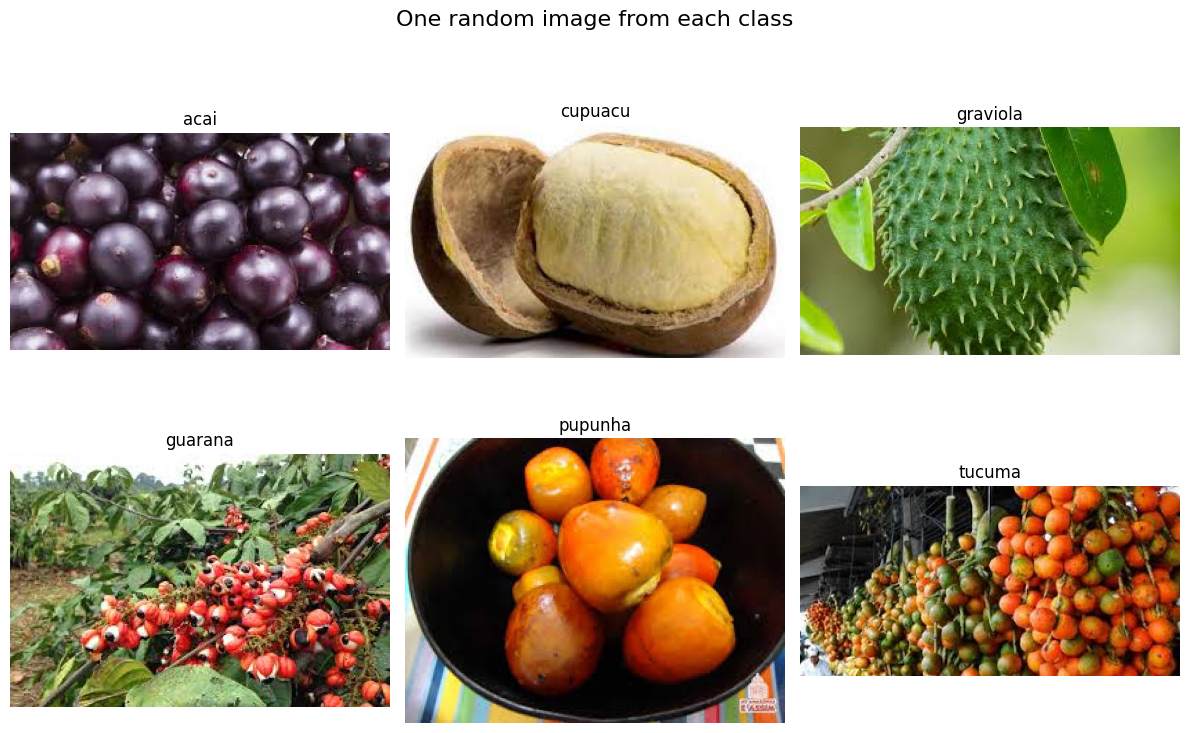

In [ ]:
# Get class directories
class_dirs = sorted([d for d in train_dir.iterdir() if d.is_dir()])
class_names = [d.name for d in class_dirs]
num_classes = len(class_names)
print("Classes found:", class_names)
print("Number of classes:", num_classes)

if num_classes == 0:
    raise ValueError(f"No class folders found inside {train_dir}")
# Select one random image from each class
sample_paths = []
for class_dir in class_dirs:
    image_files = [p for p in class_dir.iterdir() if p.is_file()]
    if len(image_files) == 0:
        print(f"Warning: No images found in {class_dir}")
        continue
    sample_paths.append(random.choice(image_files))
# Diplay in a 2-row grid
n = len(sample_paths)
rows = 2
cols = int(np.ceil(n / rows))
plt.figure(figsize=(4 * cols, 8))
for i, img_path in enumerate(sample_paths, start=1):
    plt.subplot(rows, cols, i)
    img = Image.open(img_path)
    plt.imshow(img)
    plt.title(img_path.parent.name)
    plt.axis("off")

plt.suptitle("One random image from each class", fontsize=16)
plt.tight_layout()
plt.show()

## 5. Task 2 Check and remove corrupted images


In [ ]:
def remove_corrupted_images(root_dir):
    corrupted = []

    for class_dir in sorted([d for d in Path(root_dir).iterdir() if d.is_dir()]):
        for image_path in class_dir.iterdir():
            if not image_path.is_file():
                continue
            try:
                with Image.open(image_path) as img:
                    img.verify()  # verifies file integrity
            except (IOError, SyntaxError, Image.UnidentifiedImageError, OSError):
                corrupted.append(str(image_path))
                try:
                    os.remove(image_path)
                    print(f"Removed corrupted image: {image_path}")
                except Exception as e:
                    print(f"Could not remove {image_path}: {e}")

    if len(corrupted) == 0:
        print("No Corrupted Images Found.")

    return corrupted

print("Checking train folder...")
train_corrupted = remove_corrupted_images(train_dir)

print("\nChecking test folder...")
test_corrupted = remove_corrupted_images(test_dir)

Checking train folder...
No Corrupted Images Found.

Checking test folder...
No Corrupted Images Found.


## 6. Task 3 — Load and preprocess image data using Keras
- load training data from the `train` folder
- split it into training and validation sets
- resize images to `128 x 128`
- batch with `batch_size = 16`
- normalize pixel values to `[0, 1]`


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE
# Rescaling layer for normalization
rescale = tf.keras.layers.Rescaling(1./255)
# Training dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=seed
)
# Validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=seed
)
# Test dataset
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False
)
# Keep class names
class_names = train_ds.class_names
num_classes = len(class_names)

print("Class names:", class_names)
print("Number of classes:", num_classes)
# Normalize
train_ds = train_ds.map(lambda x, y: (rescale(x), y), num_parallel_calls=AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (rescale(x), y), num_parallel_calls=AUTOTUNE)
test_ds = test_ds.map(lambda x, y: (rescale(x), y), num_parallel_calls=AUTOTUNE)
# Improve performance
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6


## 7. View one batch after preprocessing

In [ ]:
for images, labels in train_ds.take(1):
    print("Image batch shape :", images.shape)
    print("Label batch shape :", labels.shape)
    print("Pixel range       :", float(tf.reduce_min(images)), "to", float(tf.reduce_max(images)))

Image batch shape : (16, 128, 128, 3)
Label batch shape : (16,)
Pixel range       : 0.0 to 1.0


## 8. Task 3 — Build the required CNN model

- Conv2D: 32 filters, (3,3), padding = `"same"`, stride = 1
- ReLU
- MaxPooling2D: (2,2), stride = 2
- Conv2D: 32 filters, (3,3), padding = `"same"`, stride = 1
- ReLU
- MaxPooling2D: (2,2), stride = 2
- Flatten
- Dense: 64
- Dense: 128
- Output Dense: `num_classes` with softmax

In [ ]:
model = keras.Sequential([
    layers.Input(shape=(img_height, img_width, 3)),

    layers.Conv2D(filters=32, kernel_size=(3, 3), strides=(1, 1), padding="same", activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    layers.Conv2D(filters=32, kernel_size=(3, 3), strides=(1, 1), padding="same", activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

## 9. Task 4 Compile the model

- **Optimizer:** Adam
- **Loss:** sparse categorical crossentropy
- **Metric:** accuracy

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


## 10. Callbacks


In [ ]:
checkpoint_dir = Path("/content/drive/MyDrive/Worksheet5_Model_Output")
checkpoint_dir.mkdir(parents=True, exist_ok=True)

best_model_path = checkpoint_dir / "best_cnn_model.keras"
final_h5_path = checkpoint_dir / "final_cnn_model.h5"

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        filepath=str(best_model_path),
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

print("Best model path:", best_model_path)
print("Final .h5 path :", final_h5_path)

Best model path: /content/drive/MyDrive/Worksheet5_Model_Output/best_cnn_model.keras
Final .h5 path : /content/drive/MyDrive/Worksheet5_Model_Output/final_cnn_model.h5


## 11. Task 4 Train the model


In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.1514 - loss: 1.9124
Epoch 1: val_loss improved from None to 1.64239, saving model to /content/drive/MyDrive/Worksheet5_Model_Output/best_cnn_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Worksheet5_Model_Output/best_cnn_model.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 379ms/step - accuracy: 0.1528 - loss: 1.9618 - val_accuracy: 0.0000e+00 - val_loss: 1.6424
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step - accuracy: 0.2719 - loss: 1.6607
Epoch 2: val_loss improved from 1.64239 to 1.20380, saving model to /content/drive/MyDrive/Worksheet5_Model_Output/best_cnn_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Worksheet5_Model_Output/best_cnn_model.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 455ms/step - accuracy: 0.3333 - loss: 1.6272 - val_accuracy: 0.8333 - val_loss: 1.2038
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - accuracy: 0.5649 - loss: 1.2249
Epoch 3: val_loss improved from 1.20

## 12. Plot training and validation accuracy/loss



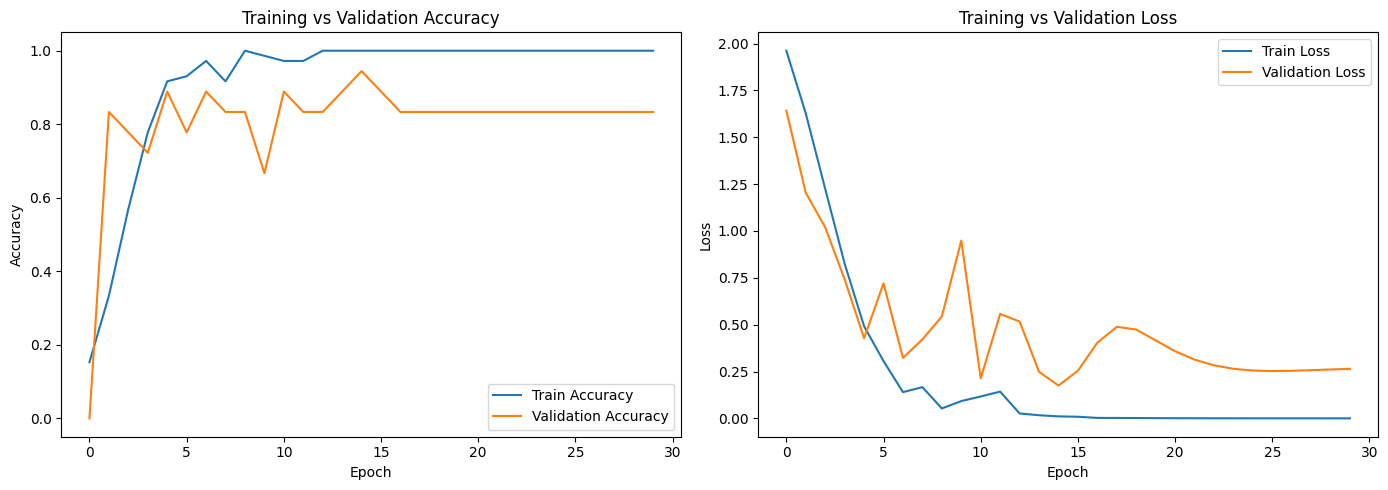

In [ ]:
history_dict = history.history

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_dict["accuracy"], label="Train Accuracy")
plt.plot(history_dict["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_dict["loss"], label="Train Loss")
plt.plot(history_dict["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.tight_layout()
plt.show()

Training vs Validation Accuracy
The blue line shows the model perfectly memorized the training data, reaching 100% accuracy.
The orange line shows it only reaches about 80% accuracy on new data, meaning it struggles to generalize.

Training vs Validation Loss
The blue line drops to near zero, showing the model makes almost no errors on the images it practiced on.
The orange line stops dropping and gets bumpy, meaning the model stopped improving its ability to handle new, unseen images.

## 13. Task 5 Evaluate the model on the test set

In [ ]:
test_loss, test_accuracy = model.evaluate(test_ds, verbose=1)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.7333 - loss: 0.8153
Test Loss     : 0.8153
Test Accuracy : 0.7333


## 14. Task 6 Save the trained model as `.h5`


In [ ]:
model.save(final_h5_path)
print(f"Model saved to: {final_h5_path}")

Model saved to: /content/drive/MyDrive/Worksheet5_Model_Output/final_cnn_model.h5


## 15. Task 6 Load the saved model and re-evaluate

In [ ]:
loaded_model = keras.models.load_model(final_h5_path)
loaded_loss, loaded_accuracy = loaded_model.evaluate(test_ds, verbose=1)

print(f"Loaded Model Test Loss     : {loaded_loss:.4f}")
print(f"Loaded Model Test Accuracy : {loaded_accuracy:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.7333 - loss: 0.8153
Loaded Model Test Loss     : 0.8153
Loaded Model Test Accuracy : 0.7333


## 16. Task 7 Predictions and classification report

In [ ]:
# Predict class probabilities on the test set
y_prob = loaded_model.predict(test_ds, verbose=1)
y_pred = np.argmax(y_prob, axis=1)

# Collect true labels from test_ds
y_true = np.concatenate([labels.numpy() for _, labels in test_ds], axis=0)

print("First 10 predicted labels:", y_pred[:10])
print("First 10 true labels     :", y_true[:10])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
First 10 predicted labels: [0 0 0 0 0 1 1 1 1 1]
First 10 true labels     : [0 0 0 0 0 1 1 1 1 1]


In [ ]:
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

              precision    recall  f1-score   support

        acai       0.62      1.00      0.77         5
     cupuacu       0.71      1.00      0.83         5
    graviola       1.00      0.80      0.89         5
     guarana       0.60      0.60      0.60         5
     pupunha       0.75      0.60      0.67         5
      tucuma       1.00      0.40      0.57         5

    accuracy                           0.73        30
   macro avg       0.78      0.73      0.72        30
weighted avg       0.78      0.73      0.72        30



Overall, the model did okay with a total accuracy of 73%, meaning it gets the right answer about three-quarters of the time.
However, it is much better at recognizing some fruits like graviola and cupuacu, but struggles a lot to correctly identify tucuma and guarana.

## 17.Confusion matrix

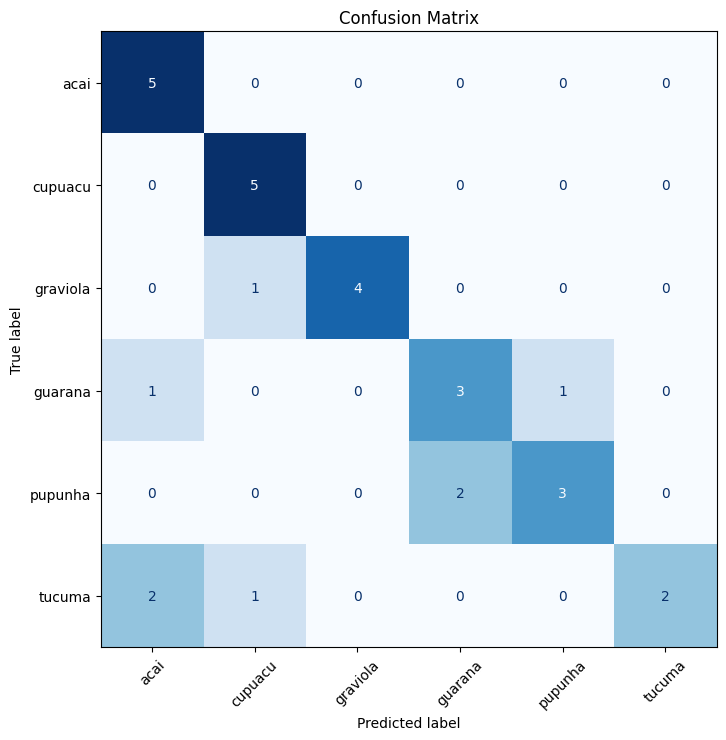

In [ ]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
plt.title("Confusion Matrix")
plt.show()

## 18. Show a few predictions

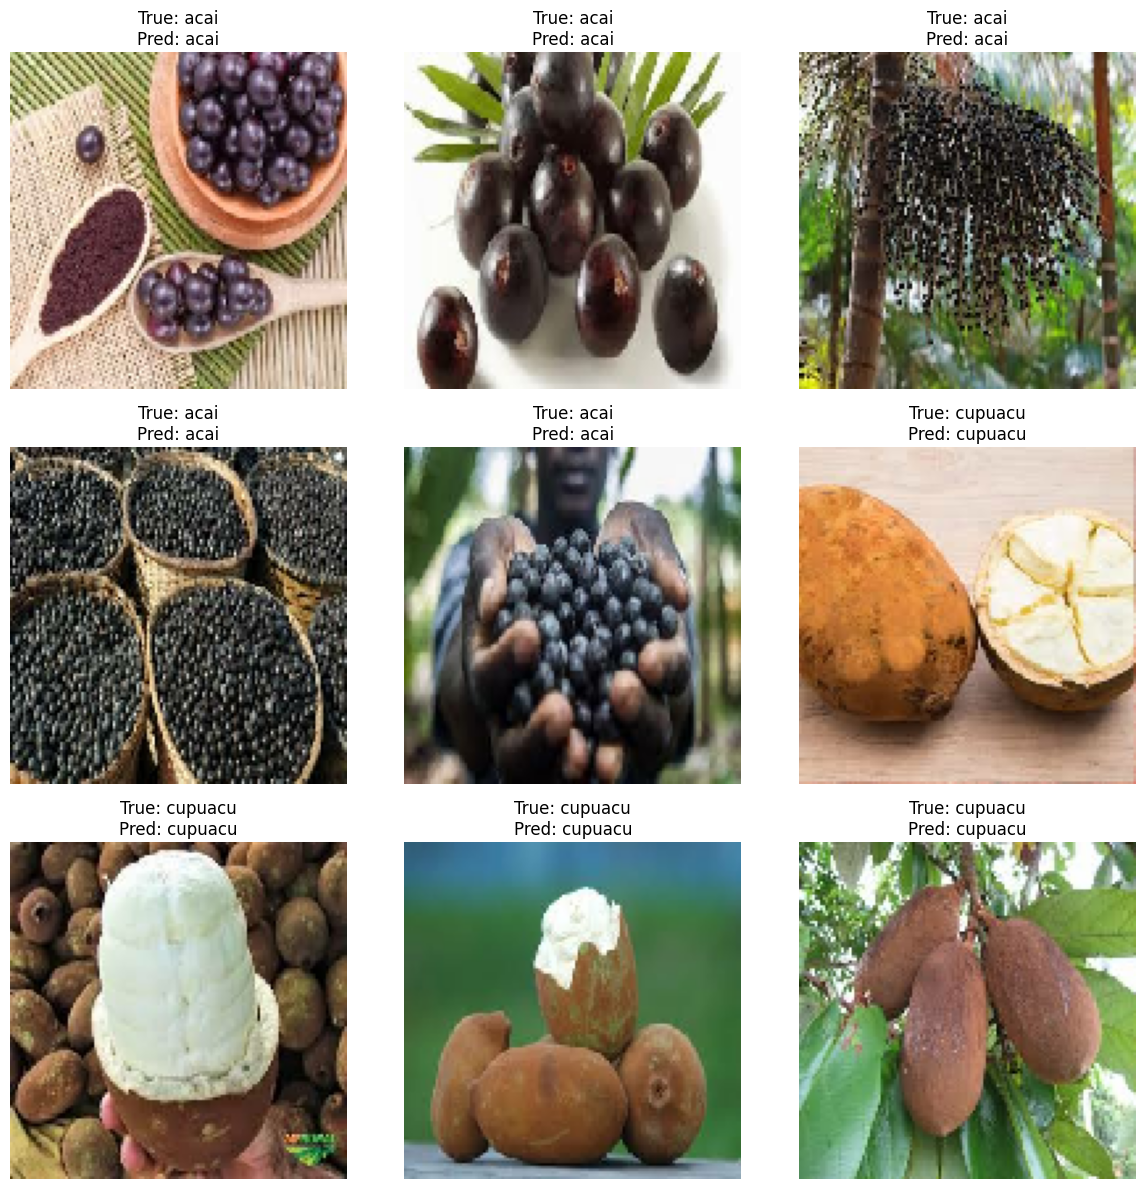

In [ ]:
# Rebuild a small unbatched list of images and labels for visualization
sample_images = []
sample_true = []

for images, labels in test_ds.unbatch().take(9):
    sample_images.append(images.numpy())
    sample_true.append(labels.numpy())

sample_images = np.array(sample_images)
sample_true = np.array(sample_true)

sample_probs = loaded_model.predict(sample_images, verbose=0)
sample_pred = np.argmax(sample_probs, axis=1)

plt.figure(figsize=(12, 12))
for i in range(len(sample_images)):
    plt.subplot(3, 3, i + 1)
    plt.imshow(sample_images[i])
    plt.title(f"True: {class_names[sample_true[i]]}\nPred: {class_names[sample_pred[i]]}")
    plt.axis("off")
plt.tight_layout()
plt.show()